**Question 1 : What is the fundamental idea behind ensemble techniques? How does bagging differ from boosting in terms of approach and objective?**

**Answer 1:**

**Fundamental Idea:**
Ensemble techniques combine predictions from multiple models (often called weak learners) to produce a stronger, more robust model. The main goal is to reduce variance, bias, or improve predictions compared to a single model.

**Bagging (Bootstrap Aggregating):**

Approach: Trains multiple independent models on different bootstrap samples (random subsets with replacement) of the dataset. Predictions are aggregated (majority vote for classification, average for regression).

Objective: Reduce variance and prevent overfitting.

Example: Random Forest is a bagging method.

**Boosting:**

Approach: Trains models sequentially, where each new model focuses on the errors/mistakes of the previous model.

Objective: Reduce bias by combining weak learners into a strong learner.

Example: AdaBoost, Gradient Boosting.

Key Difference: Bagging works in parallel and reduces variance; boosting works sequentially and reduces bias.

**Question 2: Explain how the Random Forest Classifier reduces overfitting compared to a single decision tree. Mention the role of two key hyperparameters in this process.**

**Answer 2:**

A single decision tree can overfit because it perfectly fits the training data.

Random Forest reduces overfitting by:

Training multiple trees on different bootstrap samples (diversity).

Randomly selecting a subset of features at each split (decorrelation between trees).

**Two Key Hyperparameters:**

  - n_estimators → Number of trees; more trees reduce variance.

  - max_features → Number of features considered at each split; smaller value increases diversity and reduces overfitting.

**Question 3: What is Stacking in ensemble learning? How does it differ from traditional bagging/boosting methods? Provide a simple example use case.**

**Answer 3:**

**Stacking:**

Combines multiple base models (could be different types) and trains a meta-learner to combine their predictions.

Base models make predictions, and the meta-model learns how to best combine them.

**Difference from Bagging/Boosting:**

Bagging/Boosting typically uses same-type models.

Stacking uses heterogeneous models and learns an optimal combination.

**Example Use Case:**

Base models: Logistic Regression, Random Forest, SVM

Meta-model: Gradient Boosting to combine base predictions for improved accuracy in a classification problem.


**Question 4:What is the OOB Score in Random Forest, and why is it useful? How does it help in model evaluation without a separate validation set?**

**Answer 4:**

  - OOB (Out-of-Bag) Score: The mean accuracy computed using the samples not included in the bootstrap sample for each tree.

  - Why Useful: Acts as a built-in cross-validation to estimate model performance.

  - Benefit: Eliminates the need for a separate validation set.


**Question 5: Compare AdaBoost and Gradient Boosting in terms of:**

● **How they handle errors from weak learners**

● **Weight adjustment mechanism**

● **Typical use cases**

**Answer 5:**

| Aspect               | AdaBoost                                             | Gradient Boosting                                                             |
| -------------------- | ---------------------------------------------------- | ----------------------------------------------------------------------------- |
| **Error Handling**   | Focuses on misclassified samples by updating weights | Optimizes a loss function using gradient descent                              |
| **Weight Mechanism** | Increases weight of misclassified points             | Sequentially fits models to residual errors                                   |
| **Typical Use Case** | Classification tasks with moderate noise             | Both regression and classification, sensitive to outliers but highly accurate |



**Question 6:Why does CatBoost perform well on categorical features without requiring extensive preprocessing? Briefly explain its handling of categorical variables.**

**Answer 6:**

  - CatBoost handles categorical variables without manual encoding.

  - Uses ordered target statistics and permutation-driven encoding to prevent overfitting.

  - Efficiently converts categorical features into numerical representations while preserving information.

In [1]:
'''
Question 7: KNN Classifier Assignment: Wine Dataset Analysis with
Optimization
Task:
1. Load the Wine dataset (sklearn.datasets.load_wine()).
2. Split data into 70% train and 30% test.
3. Train a KNN classifier (default K=5) without scaling and evaluate using:
a. Accuracy
b. Precision, Recall, F1-Score (print classification report)
4. Apply StandardScaler, retrain KNN, and compare metrics.
5. Use GridSearchCV to find the best K (test K=1 to 20) and distance metric
(Euclidean, Manhattan).
6. Train the optimized KNN and compare results with the unscaled/scaled versions.
'''

# Answer 7:

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load dataset
data = load_wine()
X, y = data.data, data.target

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train default KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Default KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier()
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
print("Scaled KNN Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

# 5. GridSearchCV for best K and metric
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric': ['euclidean', 'manhattan']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
print("Best Params:", grid.best_params_)

# 6. Optimized KNN
best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)
print("Optimized KNN Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


Default KNN Accuracy: 0.7407407407407407
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.75      0.71      0.73        21
           2       0.53      0.57      0.55        14

    accuracy                           0.74        54
   macro avg       0.73      0.73      0.73        54
weighted avg       0.74      0.74      0.74        54

Scaled KNN Accuracy: 0.9629629629629629
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54

Best Params: {'metric': 'manhattan', 'n_neighbors': 1}
Optimized KNN Accuracy: 0.9629629629629629
              precision    recall  f1-score   support

    

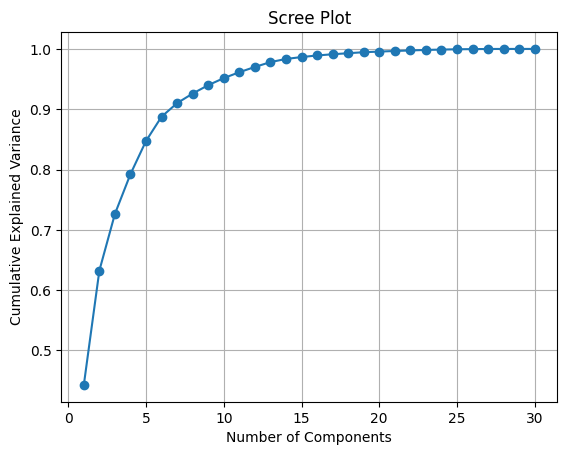

Original shape: (569, 30) Transformed shape: (569, 10)
Original Accuracy: 0.9590643274853801
PCA Accuracy: 0.9649122807017544


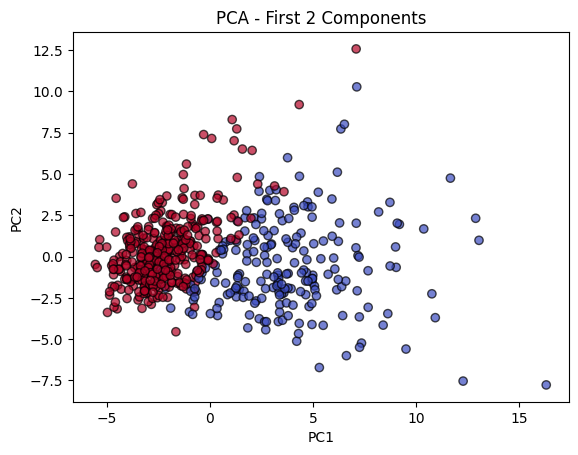

In [2]:
'''
Question 8 : PCA + KNN with Variance Analysis and Visualization
Task:
1. Load the Breast Cancer dataset (sklearn.datasets.load_breast_cancer()).
2. Apply PCA and plot the scree plot (explained variance ratio).
3. Retain 95% variance and transform the dataset.
4. Train KNN on the original data and PCA-transformed data, then compare
accuracy.
5. Visualize the first two principal components using a scatter plot (color by class).
'''

# Answer 8:

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA().fit(X_scaled)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Scree plot
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

# Retain 95% variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print("Original shape:", X_scaled.shape, "Transformed shape:", X_pca.shape)

# KNN on original vs PCA data
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Original
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print("Original Accuracy:", accuracy_score(y_test, knn.predict(X_test)))

# PCA
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, y_train)
print("PCA Accuracy:", accuracy_score(y_test, knn_pca.predict(X_test_pca)))

# Scatter plot of first 2 components
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - First 2 Components')
plt.show()


euclidean MSE: 4803.90558674207
manhattan MSE: 5210.225816542467


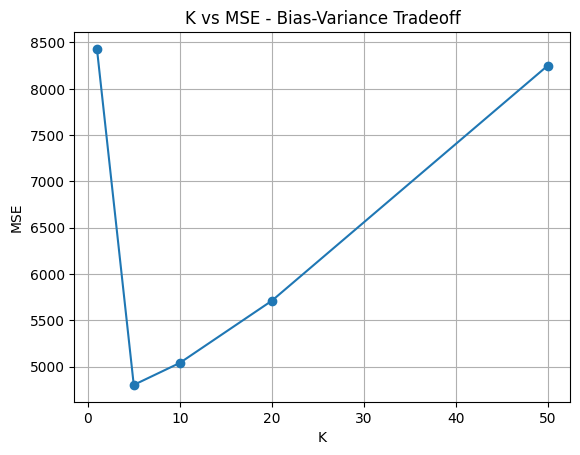

In [3]:
'''
Question 9:KNN Regressor with Distance Metrics and K-Value
Analysis
Task:
1. Generate a synthetic regression dataset
(sklearn.datasets.make_regression(n_samples=500, n_features=10)).
2. Train a KNN regressor with:
a. Euclidean distance (K=5)
b. Manhattan distance (K=5)
c. Compare Mean Squared Error (MSE) for both.
3. Test K=1, 5, 10, 20, 50 and plot K vs. MSE to analyze bias-variance tradeoff.
'''

# Answer 9:

from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Generate synthetic data
X, y = make_regression(n_samples=500, n_features=10, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. KNN regressor comparison
distances = ['euclidean', 'manhattan']
for dist in distances:
    knn = KNeighborsRegressor(n_neighbors=5, metric=dist)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(f"{dist} MSE:", mean_squared_error(y_test, y_pred))

# 3. Analyze effect of K
K_values = [1, 5, 10, 20, 50]
mse_list = []
for k in K_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    mse_list.append(mean_squared_error(y_test, y_pred))

plt.plot(K_values, mse_list, marker='o')
plt.xlabel('K')
plt.ylabel('MSE')
plt.title('K vs MSE - Bias-Variance Tradeoff')
plt.grid(True)
plt.show()


Dataset shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
BRUTE → Accuracy: 0.6926, Training Time: 0.0016 sec
KD_TREE → Accuracy: 0.6926, Training Time: 0.0017 sec
BALL_TREE → Accuracy: 0.6926, Training Time: 0.0014 sec

Best Performing Algorithm: BRUTE


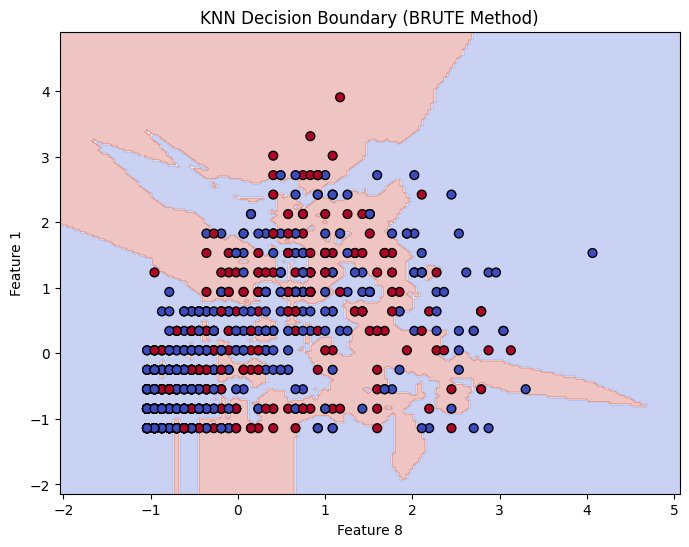

In [5]:
'''
Question 10: KNN with KD-Tree/Ball Tree, Imputation, and Real-World
Data
Task:
1. Load the Pima Indians Diabetes dataset (contains missing values).
2. Use KNN Imputation (sklearn.impute.KNNImputer) to fill missing values.
3. Train KNN using:
a. Brute-force method
b. KD-Tree
c. Ball Tree
4. Compare their training time and accuracy.
5. Plot the decision boundary for the best-performing method (use 2 most important
features).
Dataset: Pima Indians Diabetes
'''

# Answer 10:

# ========================
# KNN with KD-Tree / Ball Tree / Imputation
# Dataset: Pima Indians Diabetes
# ========================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load Dataset
url = "https://raw.githubusercontent.com/MasteriNeuron/datasets/refs/heads/main/diabetes.csv"
data = pd.read_csv(url)
print("Dataset shape:", data.shape)
print(data.head())

# Separate features and target
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# 2. KNN Imputation for missing values
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X)

# 3. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 5. Compare algorithms
algorithms = ['brute', 'kd_tree', 'ball_tree']
results = {}

for algo in algorithms:
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo)
    start = time.time()
    knn.fit(X_train, y_train)
    end = time.time()

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    train_time = end - start

    results[algo] = {'Accuracy': acc, 'Time': train_time}
    print(f"{algo.upper()} → Accuracy: {acc:.4f}, Training Time: {train_time:.4f} sec")

# 6. Identify best-performing method
best_algo = max(results, key=lambda k: results[k]['Accuracy'])
print("\nBest Performing Algorithm:", best_algo.upper())

# 7. Decision Boundary Plot (2 most important features)
# We'll use the two features with highest variance for visualization
feature_variances = np.var(X_scaled, axis=0)
top2_indices = np.argsort(feature_variances)[-2:]
X_vis = X_scaled[:, top2_indices]

knn_best = KNeighborsClassifier(n_neighbors=5, algorithm=best_algo)
knn_best.fit(X_vis, y)

# Create grid for decision boundary
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = knn_best.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=40)
plt.xlabel(f'Feature {top2_indices[0]+1}')
plt.ylabel(f'Feature {top2_indices[1]+1}')
plt.title(f'KNN Decision Boundary ({best_algo.upper()} Method)')
plt.show()
